In [15]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
# os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [16]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [17]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

def create_sliding_window(data_df, window_size,forecast_horizon=1):
    X, y = [], []
    series = data_df['EUR/MWh'].values
    for i in range(len(series) - window_size - forecast_horizon + 1):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size:i+window_size+forecast_horizon])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


In [18]:

# --- Model (MLP) similar structure to Rolling window notebook ---
class MLP(nn.Module):
    def __init__(self, input_dim, layer_dims, output_dim, dropout=0.0, use_batchnorm=False, leaky_alpha=0.0):
        super().__init__()
        layers = []
        last = input_dim
        for i, d in enumerate(layer_dims):
            layers.append(nn.Linear(last, d))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(d, eps=1e-3, momentum=0.99))
            if leaky_alpha and leaky_alpha > 0:
                layers.append(nn.LeakyReLU(leaky_alpha))
            else:
                layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = d
        layers.append(nn.Linear(last, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [19]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [20]:
def naive_baseline(y_np, shift=24*7):
    out = np.empty_like(y_np, dtype=float)
    out[:shift, :] = np.nan
    out[shift:, :] = y_np[:-shift, :]
    return out


In [21]:
def evaluate_model(model, X_np, y_np, shift=24*7, batch_size=128, device='cpu'):
    model.to(device)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)

    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    naive_arr = naive_baseline(y_np, shift=shift)
    preds_trim = predictions[shift:]
    true = y_np[shift:]
    naive_vals = naive_arr[shift:]

    mae_model = np.mean(np.abs(preds_trim - true))
    mae_naive = np.mean(np.abs(naive_vals - true))

    if mae_naive == 0:
        rmae = np.inf
        accuracy = -np.inf
    else:
        rmae = mae_model / mae_naive
        accuracy = 1.0 - rmae

    print(f"MAE model: {mae_model:.6f}, MAE naive: {mae_naive:.6f}")
    print(f"Relative MAE (rMAE): {rmae:.4f}, Accuracy (1-rMAE): {accuracy:.4f}")
    return {"predictions": preds_trim, "mae_model": mae_model, "mae_naive": mae_naive, "rmae": rmae, "accuracy": accuracy}

In [22]:

# --- Training routine adapted to fullRun.py style, using MAE and optional L1 ---
def run_full_train(
        X_train_np, y_train_np, X_dev_np, y_dev_np,
        layer_dims,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        train_amt,
        epochs,
        verbose_freq = 1
    ):
    input_dim = X_train_np.shape[1]
    output_dim = y_train_np.shape[1]
    MODEL = MLP(input_dim=input_dim, layer_dims=layer_dims, output_dim=output_dim,
                dropout=dropout, use_batchnorm=use_batchnorm, leaky_alpha=leaky_alpha).to(device)
    optimizer = torch.optim.Adam(MODEL.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)

    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)

    train_hist = []
    val_hist = []

    X_train_use = X_train_np[:train_amt]
    y_train_use = y_train_np[:train_amt]

    X_dev_t = torch.from_numpy(X_dev_np).float().to(device)
    y_dev_t = torch.from_numpy(y_dev_np).float().to(device)

    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train_use))
        X_shuf = X_train_use[perm]
        y_shuf = y_train_use[perm]

        MODEL.train()
        epoch_train_loss = 0.0
        n_seen = 0
        for i in range(0, len(X_shuf), batch_size):
            xb = torch.from_numpy(X_shuf[i:i+batch_size]).float().to(device)
            yb = torch.from_numpy(y_shuf[i:i+batch_size]).float().to(device)

            optimizer.zero_grad()
            pred = MODEL(xb)
            loss = mae_loss_fn(pred, yb)
            if l1_lambda and l1_lambda > 0:
                l1 = torch.tensor(0., device=device)
                for p in MODEL.parameters():
                    l1 = l1 + torch.sum(torch.abs(p))
                loss = loss + l1_lambda * l1
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            epoch_train_loss += loss.item() * bs
            n_seen += bs

        epoch_train_loss /= n_seen
        train_hist.append(epoch_train_loss)

        # validation
        MODEL.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0
            for i in range(0, len(X_dev_np), batch_size):
                xb = torch.from_numpy(X_dev_np[i:i+batch_size]).float().to(device)
                yb = torch.from_numpy(y_dev_np[i:i+batch_size]).float().to(device)
                pred = MODEL(xb)
                loss = mae_loss_fn(pred, yb)
                val_loss += loss.item() * xb.size(0)
                n_val += xb.size(0)
            val_loss /= n_val
        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if verbose_freq is not None and epoch % verbose_freq == 0:
            print(f"Epoch {epoch+1}/{epochs} train_loss={epoch_train_loss:.6f} val_loss={val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [46]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)

df_FR = pd.read_csv(DATA_CSV_FR)

train_df_FR, dev_df_FR, test_df_FR = split_data(df_FR)
#Normalization
mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR

# --- Create sliding windows per country ---
t = 168
forecast_horizon = 1
X_train_FR, y_train_FR = create_sliding_window(train_df_FR, t, forecast_horizon=forecast_horizon)
X_dev_FR,   y_dev_FR   = create_sliding_window(dev_df_FR, t, forecast_horizon=forecast_horizon)
X_test_FR,  y_test_FR  = create_sliding_window(test_df_FR, t, forecast_horizon=forecast_horizon)
print("Combined training samples:", X_train_FR.shape, y_train_FR.shape)
print("Combined dev samples:", X_dev_FR.shape, y_dev_FR.shape)
print("Combined test samples:", X_test_FR.shape, y_test_FR.shape)
# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {
        "layer_dims": [48,24],  #[168,24,1] (lr 1e-4) works good [168,48,24] (lr (5e-5)) as well
        "dropout": 0.0,
        "use_batchnorm": False,
        "leaky_alpha": 0.0,
        "learning_rate": 1e-4,
        "weight_decay": 0.0,
        "l1_lambda": 0.0,
        "batch_size": 128,
        "train_amt": len(X_train_FR),   # use all by default
        "epochs": 100
     },
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
        layer_dims = params["layer_dims"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Combined training samples: (34892, 168) (34892, 1)
Combined dev samples: (8615, 168) (8615, 1)
Combined test samples: (8591, 168) (8591, 1)
Running experiment: default
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0
)
Batch size: 128 Epochs: 100
Epoch 1/100 train_loss=0.301823 val_loss=0.185006
Epoch 2/100 train_loss=0.176731 val_loss=0.134973
Epoch 3/100 train_loss=0.133029 val_loss=0.111556
Epoch 4/100 train_loss=0.116594 val_loss=0.103382
Epoch 5/100 train_loss=0.106100 val_loss=0.094601
Epoch 6/100 train_loss=0.099013 val_loss=0.089723
Epoch 7/100 train_

<Figure size 640x480 with 0 Axes>

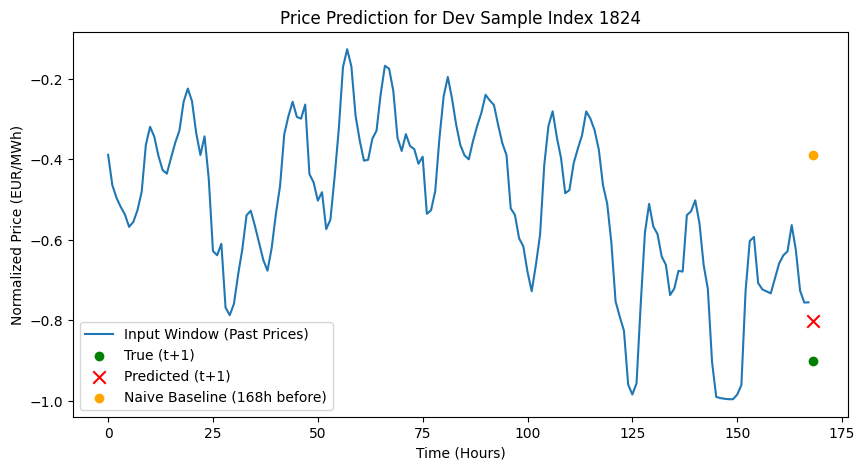

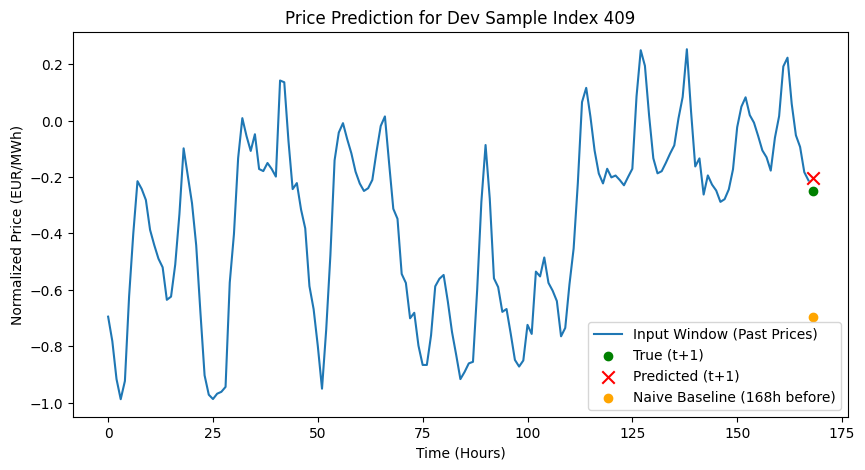

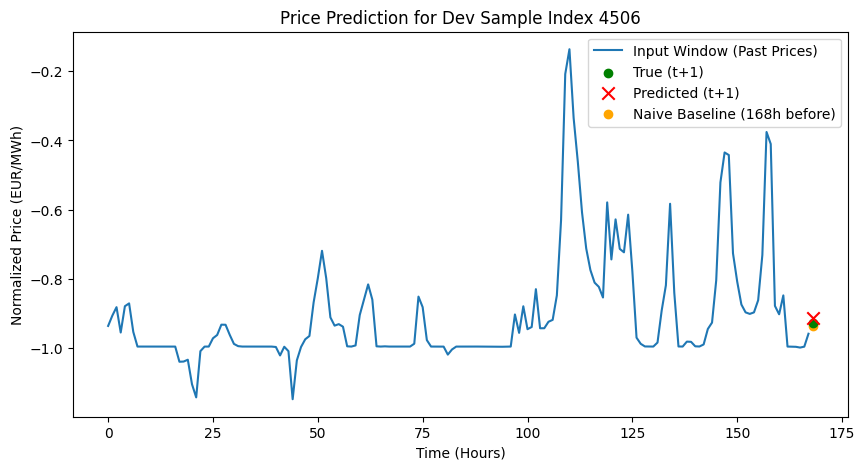

In [40]:

# Pick three days at random on the dev set and plot single-point forecast + naive baseline
num_days = len(X_dev_FR)
random_indices = random.sample(range(num_days), 3)
naive_arr = naive_baseline(y_dev_FR, shift=24*7)   # do NOT shadow the function name

for idx in random_indices:
    input_window = X_dev_FR[idx]
    true_value = float(y_dev_FR[idx].flatten()[0])  # scalar target
    naive_value = float(np.squeeze(naive_arr[idx]))  # scalar (may be nan for early indices)

    model.eval()
    with torch.no_grad():
        input_tensor = torch.from_numpy(input_window).float().unsqueeze(0).to(device)
        pred_val = float(model(input_tensor).cpu().numpy().flatten()[0])

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(t), input_window, label='Input Window (Past Prices)')
    plt.scatter([t], [true_value], color='green', label='True (t+1)', zorder=5)
    plt.scatter([t], [pred_val], color='red', marker='x', s=80, label='Predicted (t+1)', zorder=6)
    plt.scatter([t], [naive_value], color='orange', label='Naive Baseline (168h before)', zorder=4)
    plt.title(f'Price Prediction for Dev Sample Index {idx}')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Normalized Price (EUR/MWh)')
    plt.legend()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 640x480 with 0 Axes>

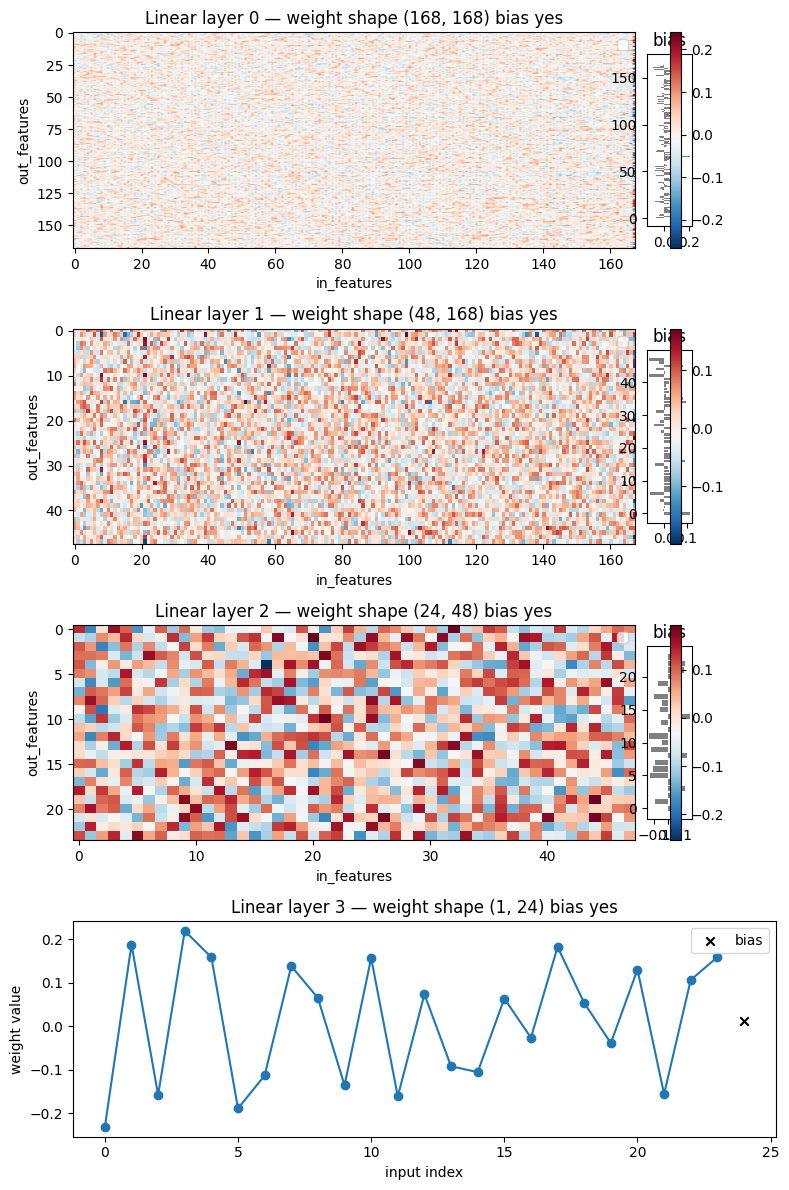

Layer 0: W shape=(168, 168) ||W||=7.940720 bias=0.788050
Layer 1: W shape=(48, 168) ||W||=4.609655 bias=0.342360
Layer 2: W shape=(24, 48) ||W||=3.100073 bias=0.474405
Layer 3: W shape=(1, 24) ||W||=0.686435 bias=0.012542


In [41]:


# ensure model is available
_ = model

# move to CPU for plotting
model_cpu = model.to('cpu')

# collect all Linear layers in the sequential network (in order)
linears = [m for m in model_cpu.net if isinstance(m, nn.Linear)]
if len(linears) == 0:
    raise RuntimeError("No nn.Linear layers found in model.net")

# prepare plot
plt.clf()
fig, axes = plt.subplots(len(linears), 1, figsize=(8, 3 * len(linears)))
if len(linears) == 1:
    axes = [axes]

for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()   # shape: (out_features, in_features)
    b = lin.bias.detach().numpy() if lin.bias is not None else None

    axes[i].set_title(f"Linear layer {i} — weight shape {W.shape} bias {'yes' if b is not None else 'no'}")
    # if single-row output (common for final layer with single output) plot vector
    if W.ndim == 2 and W.shape[0] == 1:
        axes[i].plot(W.flatten(), marker='o', linestyle='-')
        axes[i].set_xlabel("input index")
        axes[i].set_ylabel("weight value")
    else:
        im = axes[i].imshow(W, aspect='auto', cmap='RdBu_r')
        fig.colorbar(im, ax=axes[i])
        axes[i].set_xlabel("in_features")
        axes[i].set_ylabel("out_features")

    # overlay bias as x marks (if present)
    if b is not None:
        # place biases to the right of inputs for visualization (will align on x axis for vector plots)
        if W.shape[0] == 1:
            axes[i].scatter([len(W.flatten())], [b.item()] if b.size == 1 else b.flatten()[0], color='k', marker='x', label='bias')
        else:
            # plot bias values as a separate small bar plot on the right of the heatmap
            bx = axes[i].inset_axes([1.02, 0.1, 0.08, 0.8])
            bx.barh(np.arange(len(b)), b, color='gray')
            bx.set_title("bias")
        axes[i].legend()

plt.tight_layout()
plt.savefig("model_weights.png", bbox_inches='tight')
plt.show()

# print numeric summaries
for i, lin in enumerate(linears):
    W = lin.weight.detach().numpy()
    b = lin.bias.detach().numpy() if lin.bias is not None else None
    print(f"Layer {i}: W shape={W.shape} ||W||={np.linalg.norm(W):.6f} bias={'none' if b is None else np.linalg.norm(b):.6f}")


In [42]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_test_FR, y_test_FR, device=device)
exp_results[tag]["eval_test"] = eval_res_test

Evaluating on test set:
MAE model: 0.064323, MAE naive: 0.254058
Relative MAE (rMAE): 0.2532, Accuracy (1-rMAE): 0.7468


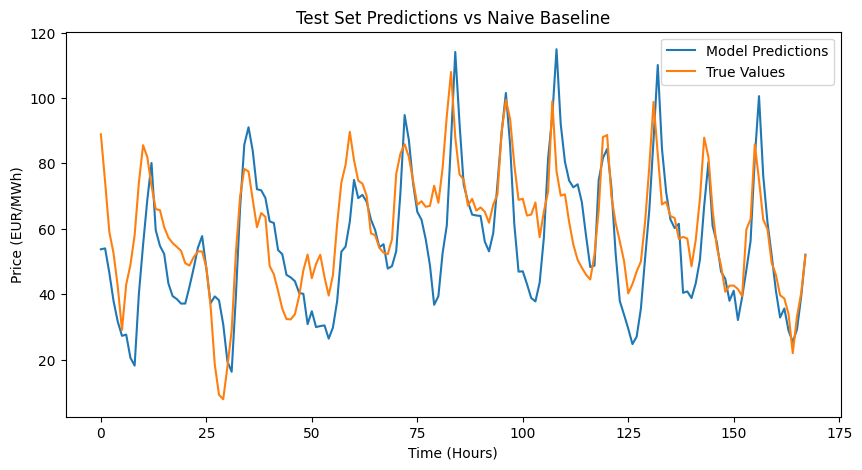

In [44]:
#Take a random 168 hours window

start = random.randint(0, len(y_dev_FR) - 168 - 1)
window_168 = y_dev_FR[start:start+168]
preds=eval_res['predictions'][start:start+168]
naive_arr = naive_baseline(y_dev_FR, shift=24*7)
naive=naive_arr[start:start+168]
window_168=window_168*std_FR + mean_FR
preds=preds*std_FR + mean_FR
naive=naive*std_FR + mean_FR
#Plot the final predictions on test set
plt.figure(figsize=(10, 5))
plt.plot(preds, label='Model Predictions')
# plt.plot(naive, label='Naive Baseline (168h before)')
plt.plot(window_168, label='True Values')
plt.title('Test Set Predictions vs Naive Baseline')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [ ]:
#Hyperparameer searching
architectures = [[1],
                [24],
                [48,24],
                [168,24,1],
                [168,48,24]]
lr=np.logspace(-5,-3,5)
results={}
#Train for each of the parameter combinations on 50 epochs
for arch in architectures:
    for learning_rate in lr:
        print(f"Training architecture {arch} with learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train_FR, y_train_FR, X_dev_FR, y_dev_FR,
            layer_dims = arch,
            dropout = 0.0,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 50,
            verbose_freq = 10
        )
        print("Evaluating on dev set:")
        eval_res = evaluate_model(model, X_dev_FR, y_dev_FR, device=device)
        print("\n")
        results[(tuple(arch), learning_rate)] = eval_res
#Find the best architecture and learning rate
min_rmae=min([v['rmae'] for v in results.values()])
best_configs=[k for k,v in results.items() if v['rmae']==min_rmae]
print(f"Best configurations (rMAE={min_rmae}):")
for config in best_configs:
    print(f"Architecture: {config[0]}, Learning Rate: {config[1]}")


Training architecture [1] with learning rate 1e-05
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_features=1, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1, out_features=1, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0
)
Batch size: 128 Epochs: 50
Epoch 1/50 train_loss=0.996987 val_loss=1.091142
Epoch 11/50 train_loss=0.411592 val_loss=0.289455
Epoch 21/50 train_loss=0.405910 val_loss=0.276901
Epoch 31/50 train_loss=0.399168 val_loss=0.261474
Epoch 41/50 train_loss=0.392224 val_loss=0.245652
Evaluating on dev set:
MAE model: 0.230895, MAE naive: 0.217107
Relative MAE (rMAE): 1.0635, Accuracy (1-rMAE): -0.0635


Training architecture [1] with learning rate 3.1622776601683795e-05
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=168, out_featur

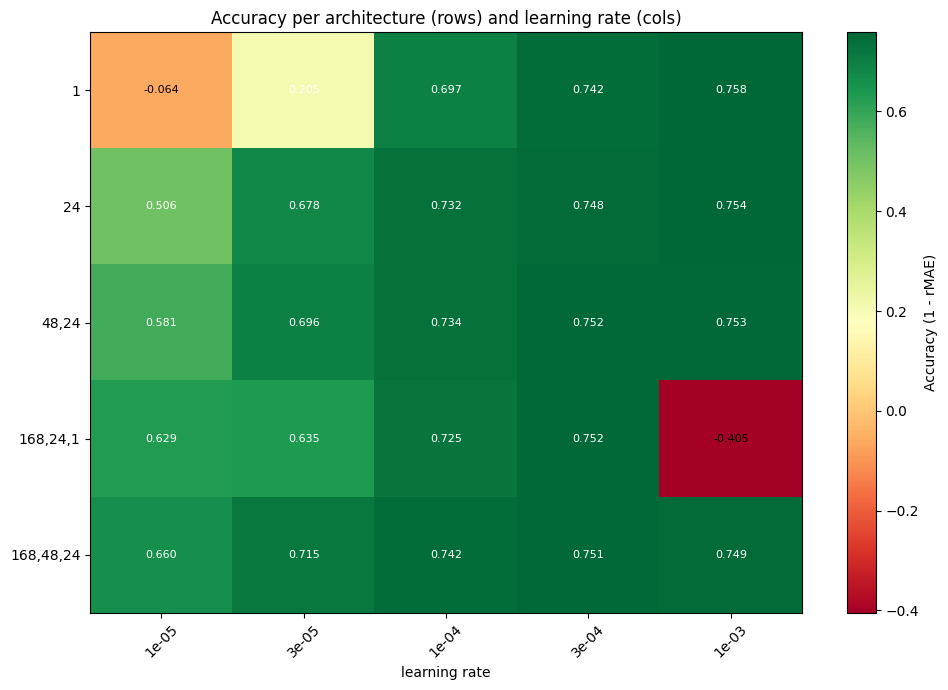

In [ ]:
#Plot now the results : lr vs archtectures 
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()}, key=lambda a: (len(a), a))
lrs = sorted({float(k[1]) for k in results.keys()})

# build matrix arch x lr of Accuracy = 1 - rMAE (use stored 'accuracy' if present)
amatrix = np.full((len(archs), len(lrs)), np.nan, dtype=float)
for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    # try to get eval-dict (handles both formats)
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and ("accuracy" in v or "rmae" in v):
        ev = v
    else:
        ev = None

    if ev is None:
        acc = np.nan
    else:
        if "accuracy" in ev and ev["accuracy"] is not None:
            acc = ev["accuracy"]
        elif "rmae" in ev and ev["rmae"] is not None:
            acc = 1.0 - ev["rmae"]
        else:
            acc = np.nan

    i = archs.index(arch)
    j = lrs.index(float(lr))
    amatrix[i, j] = acc

# heatmap (use diverging/green colormap; allow negatives)
vmin = np.nanmin(amatrix)
vmax = np.nanmax(amatrix)
plt.figure(figsize=(10, 4 + 0.6 * len(archs)))
im = plt.imshow(amatrix, aspect='auto', cmap='viridis', origin='upper', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Accuracy (1 - rMAE)')
plt.yticks(range(len(archs)), [",".join(map(str,a)) for a in archs])
plt.xticks(range(len(lrs)), [f"{lr:.0e}" for lr in lrs], rotation=45)
plt.xlabel("learning rate")
plt.title("Accuracy per architecture (rows) and learning rate (cols)")
for i in range(len(archs)):
    for j in range(len(lrs)):
        val = amatrix[i,j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.3f}", ha='center', va='center',
                     color='black' if (vmax - vmin) == 0 or val < (vmin+vmax)/2 else 'white', fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_heatmap.png", bbox_inches='tight')
plt.show()